In [15]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from helpers import (
    avg_frames_from_paths, compute_polynomial_coeffs, apply_fit, compute_img_metrics
)

In [6]:
exp1_path = Path('../../../../Experimental/LabData/contactTesting/20260904')
exp2_path = Path('../../../../Experimental/LabData/contactTesting/20260921')

# CALIBRATION #
# 04/09/26
cal1_paths = list(exp1_path.glob('calibration/cal_1*.asm'))
redos = [500, 700, 900]
redo_names = [f'cal_1_{x}N.asm' for x in redos]
cal1_paths = [x for x in cal1_paths if x.name not in redo_names]
def F_from_path(path):
    return int(path.name.split('N')[0].split('_')[-1])
cal1_Fs = [F_from_path(x) for x in cal1_paths]

# 21/09/26
cal2_paths = list(exp2_path.glob('tekscan/calibration/*.asm'))
def F_from_path2(path):
    return int(path.name[3:].split('.')[0].split('_')[0])
cal2_Fs = [F_from_path2(x) for x in cal2_paths]

# TESTING #
# testing on high-1
test_paths = {
    '14548R_neu_1': list(exp1_path.glob(f'testing/14548R/neu_1*.asm')),
    '14548R_neu_2': list(exp2_path.glob(f'tekscan/testing/14548R/neu*_1.asm')),

    '50017L_fle_1': list(exp1_path.glob(f'testing/50017L/fle_1*.asm')),
    '50017L_fle_2': list(exp2_path.glob(f'tekscan/testing/50017L/fle*_2.asm')),

    '50017L_ext_1': list(exp2_path.glob(f'tekscan/testing/50017L/ext*_1.asm')),
    '50017L_ext_2': list(exp2_path.glob(f'tekscan/testing/50017L/ext*_2.asm')),
}
test_Fs = {
    '14548R_neu_1': [F_from_path(x) for x in test_paths['14548R_neu_1']],
    '14548R_neu_2': [F_from_path2(x) for x in test_paths['14548R_neu_2']],

    '50017L_fle_1': [F_from_path(x) for x in test_paths['50017L_fle_1']],
    '50017L_fle_2': [F_from_path2(x) for x in test_paths['50017L_fle_2']],

    '50017L_ext_1': [F_from_path2(x) for x in test_paths['50017L_ext_1']],
    '50017L_ext_2': [F_from_path2(x) for x in test_paths['50017L_ext_2']],
}


In [21]:
sensor_id = 3
start_time = 55
avg_window = 5
custom_masks = custom_masks = [[4, -1, 0]] # [[raw_mask_value, j_idx, k_idx], ...]
raw_mask = 0
fit_type = ('poly', False, 3, True) # (type, weight by patch size, degree, zero-intercept)
cal_F_range = (120, 500)

hold_time1 = 180
hold_time2 = 100

fit1_Fs = sorted([x for x in cal1_Fs if x>=cal_F_range[0] and x<=cal_F_range[1]])
cal1_frames = avg_frames_from_paths(
    cal1_paths, fit1_Fs, sensor_id, hold_time1, start_time, avg_window, custom_masks, raw_mask, use_F2=False
    )
coeffs1 = compute_polynomial_coeffs(
        cal1_frames, degree=fit_type[2], zero_intercept=fit_type[3], weight_by_patch_size=fit_type[1]
    )

test_frames = {}
test_frames_mpa = {}
test_mets = {}
for test in test_paths:
    paths = test_paths[test]
    Fs = [x for x in sorted(test_Fs[test]) if x <= 100]
    try:
        test_frames[test] = avg_frames_from_paths(
            paths, Fs, sensor_id, hold_time1, start_time, avg_window, custom_masks, raw_mask, use_F2=False
            )
        #print(1, test) # check try except works
    except:
        test_frames[test] = avg_frames_from_paths(
            paths, Fs, sensor_id, hold_time2, start_time, avg_window, custom_masks, raw_mask, use_F2=True
            )
        #print(2, test) # check try except works
    
    test_frames_mpa[test] = apply_fit(coeffs1, fit_type[0], test_frames[test])
    test_mets[test] = {f: compute_img_metrics(frame) for f, frame in test_frames_mpa[test].items()}

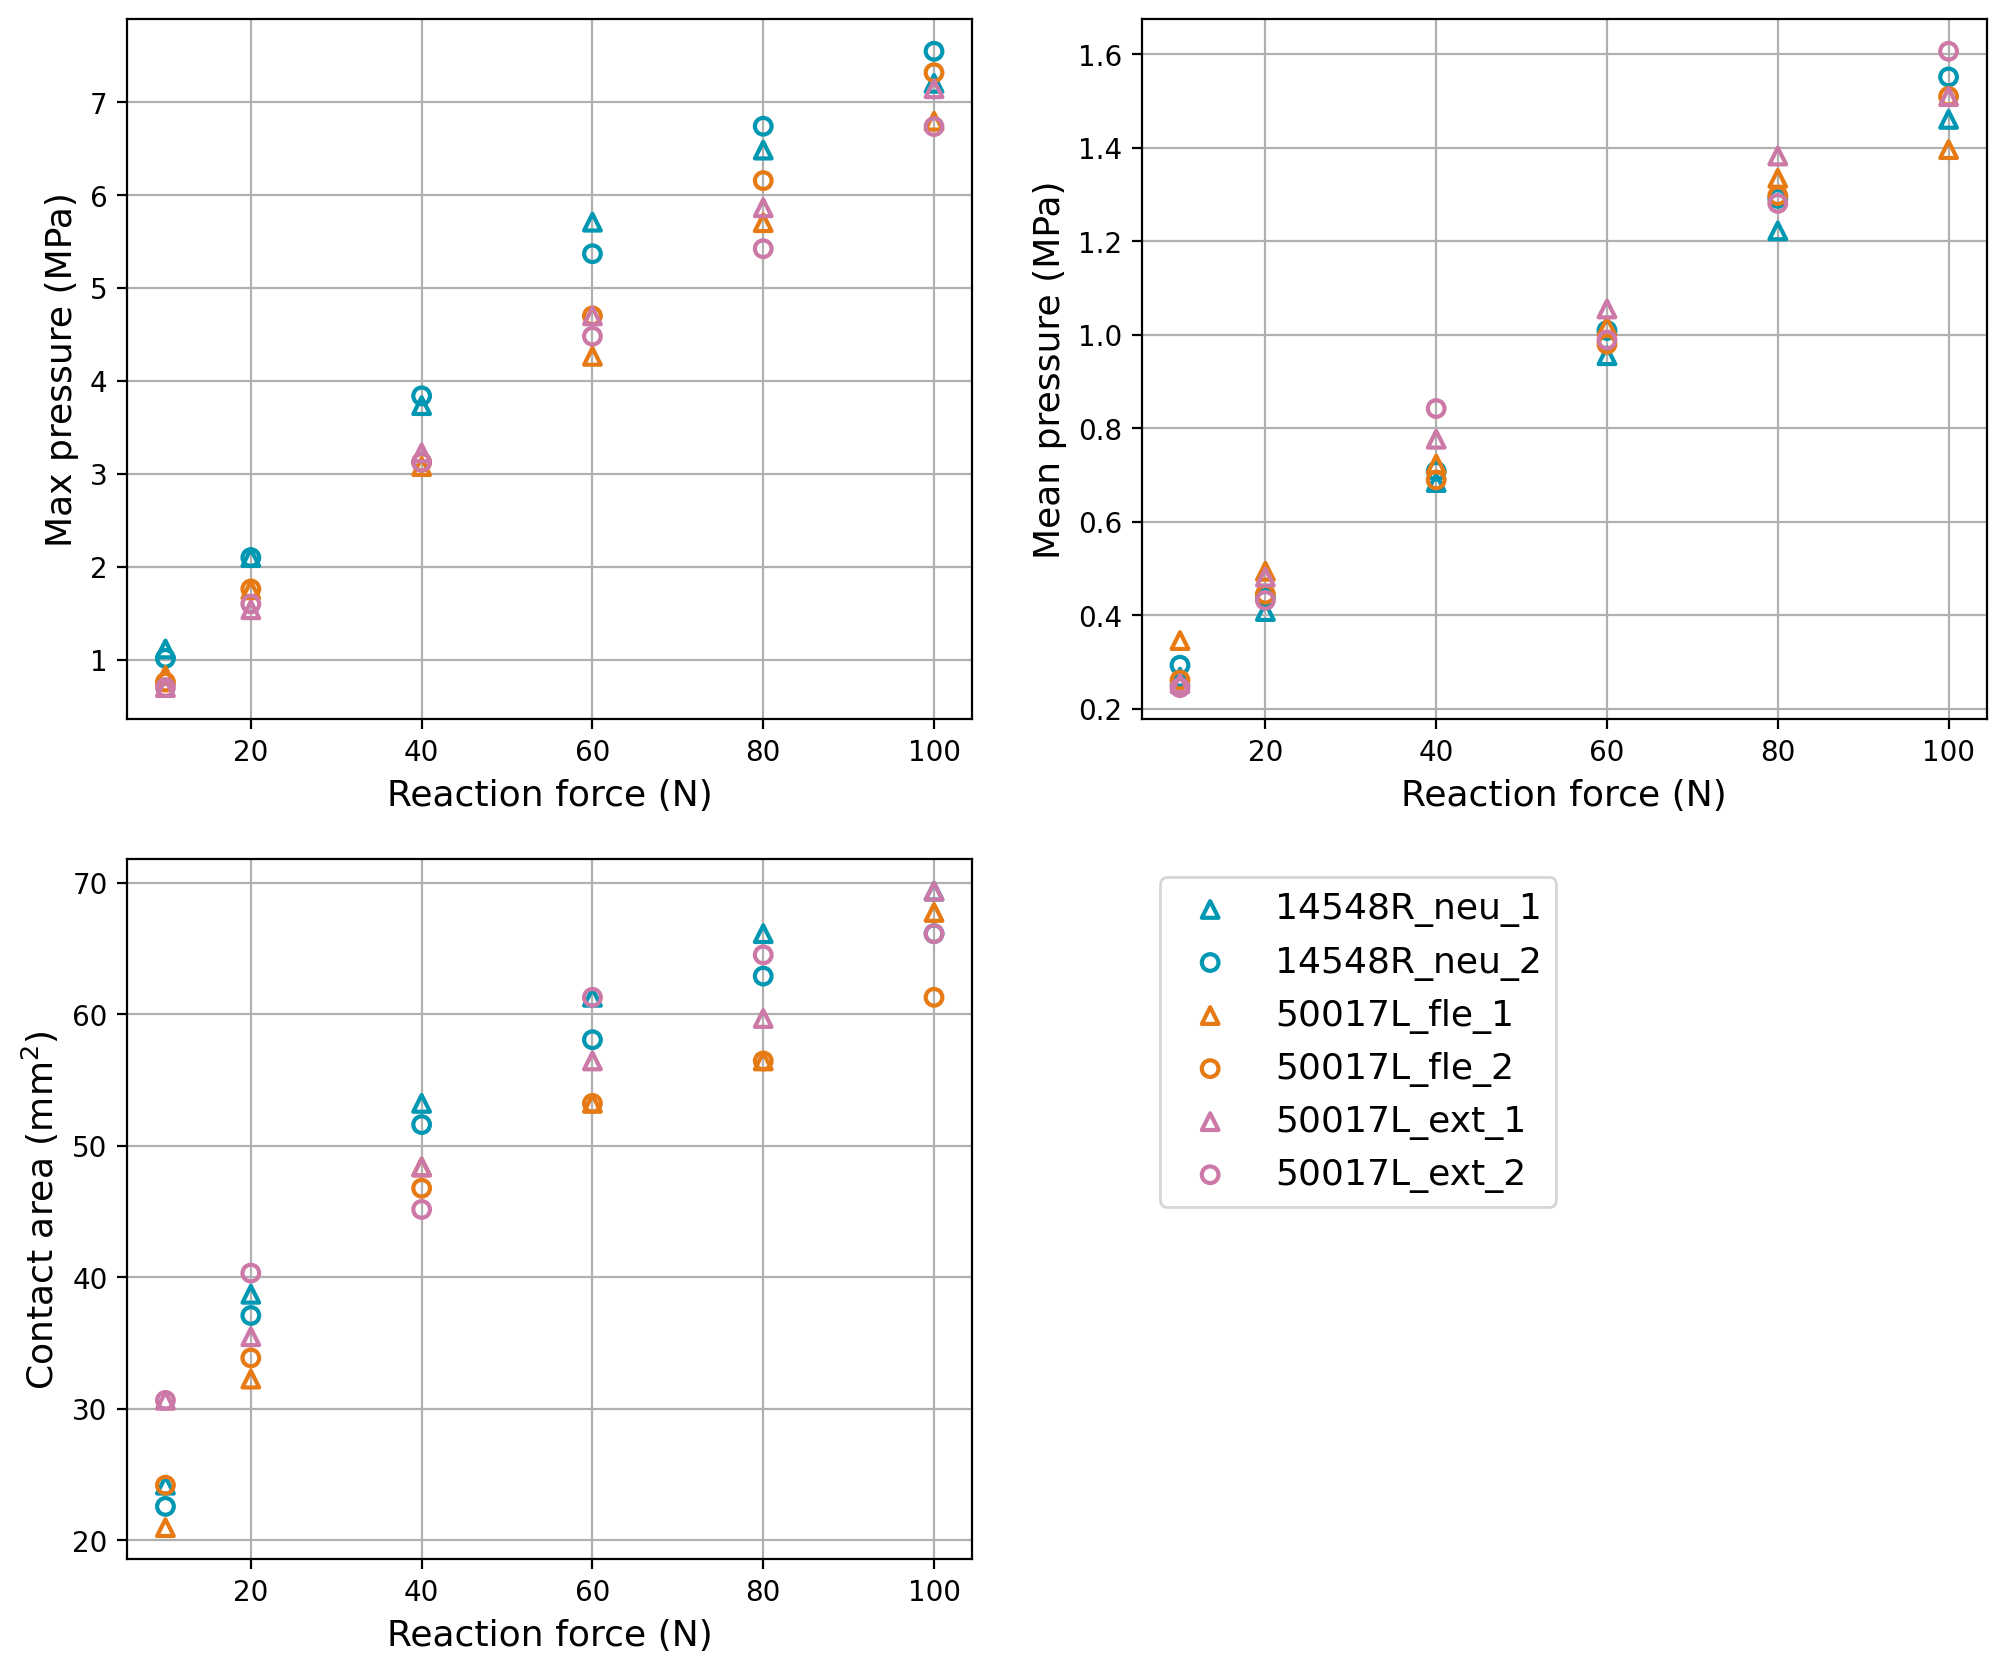

In [35]:
nrows, ncols = 2, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*5), dpi=200)

ax = ax.flatten()


fs = 13
colors = {
    "14548R_neu": "#0097b2",
        #"#009e73"
    "50017L_fle": "#e67a14",
    '50017L_ext': "#cc79a7"
        #"#cc79a7"
        #"#bfb200"
    }
markers = {
    "2": "o", 
    "1": "^",
    #'50017L_ext': "S"
}

mets = ['P_max', 'P_avg', 'CA']
for mets_label, mets_data in test_mets.items():
    x = mets_data.keys()
    for i, met in enumerate(mets):
        y = [mets_data[f][met] for f in x]
        ax[i].scatter(
            x, y,
            facecolors='none',
            edgecolors=colors[mets_label[:-2]],
            linewidths=1.5,
            marker=markers[mets_label[-1]],
            label=mets_label,
            zorder=2
        )
    ax[3].scatter([],[],facecolors='none',edgecolors=colors[mets_label[:-2]],linewidths=1.5,marker=markers[mets_label[-1]],label=mets_label)
        #ax[2].errorbar(F, tek_mets['CA'], yerr=[[tek_mets['CA_e_low']], [tek_mets['CA_e_high']]] , c=colors['tek'], marker=markers['tek'], capsize=5, elinewidth=0.8)

#for f in x:
#    ax[3].scatter(f, compute_CA_overlap(fe_grid_data[f], test_frames_mpa[f]), c="#009e73", marker="D")

ax[0].set_ylabel('Max pressure (MPa)', fontsize=fs)
ax[1].set_ylabel('Mean pressure (MPa)', fontsize=fs)
ax[2].set_ylabel('Contact area (mm$^2$)', fontsize=fs)
#ax[3].set_ylabel('Contact area overlap %', fontsize=fs)
ax[3].axis('off')
for ax_i in ax[:-1]:
    ax_i.set_xlabel('Reaction force (N)', fontsize=fs)
    ax_i.grid()
ax[3].legend(fontsize=fs, loc='upper left')
#ax[3].legend(fontsize=fs)
plt.show()

In [106]:
mets = ['P_max', 'P_avg', 'CA']
diffs = {}

js = np.unique(list([x[:-2] for x in test_mets.keys()]))
for j in js:
    diffs[str(j)] = {}
    rs = [x for x in test_mets if j in x]
    r1 = test_mets[rs[0]]
    r2 = test_mets[rs[1]]
    fs = set(r1) & set(r2)
    for met in mets:
        max_diff = [0, 0]
        for f in fs:
            v1 = r1[f][met]
            v2 = r2[f][met]

            diff = 100 * abs(v1 - v2) / np.mean([v1, v2])
            diff = abs(v1 -v2)
            if diff > max_diff[1]: 
                max_diff[1] = float(diff)
                max_diff[0] = f
        diffs[j][met] = max_diff


In [107]:
j = list(diffs.keys())[2]
print(j)
diffs[j]

50017L_fle


{'P_max': [100, 0.5225996260465449],
 'P_avg': [100, 0.11379953739945559],
 'CA': [100, 6.451599999999999]}

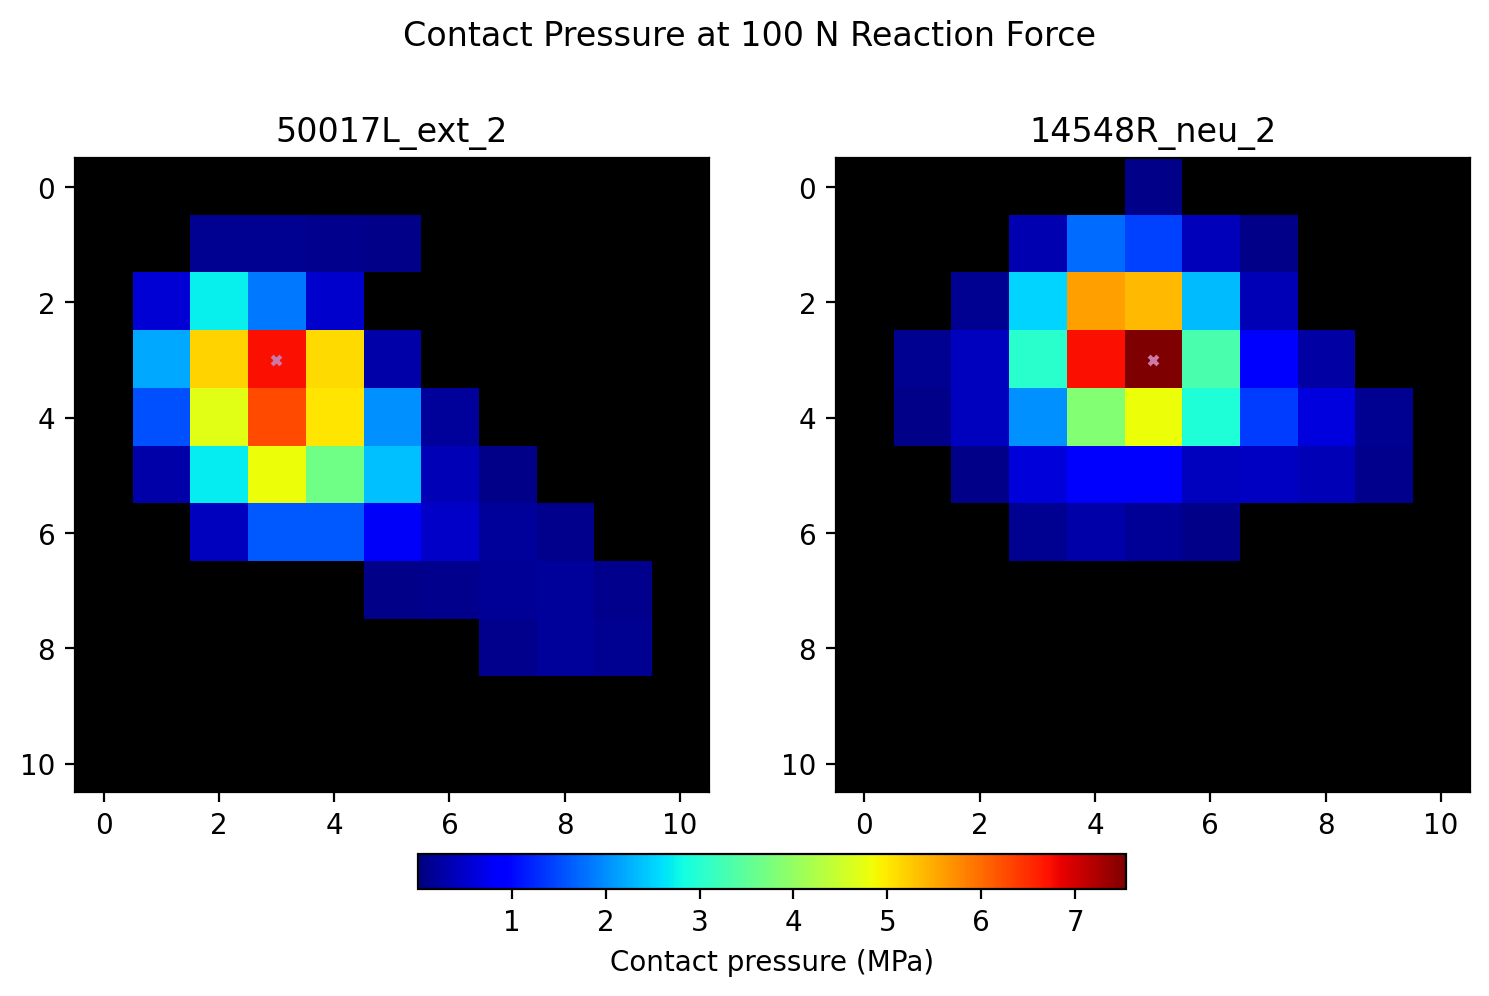

In [101]:
F = 100
r = 2
j1 = f'50017L_ext_{r}'
j2 = f'14548R_neu_{r}'

nrows, ncols = 1, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 5*nrows), dpi=200)

j1_grid, j2_grid = test_frames_mpa[j1][F][::-1], test_frames_mpa[j2][F][::-1]

press_min = np.min( [np.min(j1_grid), np.min(j2_grid)] )
press_max = np.max( [np.max(j1_grid), np.max(j2_grid)] )
clims = (1e-5, press_max)

# imshows
cmap = plt.cm.jet.copy()
cmap.set_under('black')
im = ax[0].imshow(j1_grid, vmin=clims[0], vmax=clims[1], cmap=cmap)
ax[1].imshow(j2_grid, vmin=clims[0], vmax=clims[1], cmap=cmap)

# peak pressure loc
y, x = compute_img_metrics(j1_grid)['COP']
ax[0].scatter(x, y, color="#cc79a7", s=10, marker='x')
y, x = compute_img_metrics(j2_grid)['COP']
ax[1].scatter(x, y, color="#cc79a7", s=10, marker='x')

ax[0].set_title(j1)
ax[1].set_title(j2)
fig.suptitle(f'Contact Pressure at {F} N Reaction Force')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.08, orientation='horizontal')
cbar.set_label('Contact pressure (MPa)')

plt.show()

In [100]:
print(np.sum(j1_grid > 0))
print(np.sum(j2_grid > 0))

43
43
